In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
from sklearn.datasets import load_diabetes
data = load_diabetes()

In [5]:
data

{'data': array([[ 0.03807591,  0.05068012,  0.06169621, ..., -0.00259226,
          0.01990749, -0.01764613],
        [-0.00188202, -0.04464164, -0.05147406, ..., -0.03949338,
         -0.06833155, -0.09220405],
        [ 0.08529891,  0.05068012,  0.04445121, ..., -0.00259226,
          0.00286131, -0.02593034],
        ...,
        [ 0.04170844,  0.05068012, -0.01590626, ..., -0.01107952,
         -0.04688253,  0.01549073],
        [-0.04547248, -0.04464164,  0.03906215, ...,  0.02655962,
          0.04452873, -0.02593034],
        [-0.04547248, -0.04464164, -0.0730303 , ..., -0.03949338,
         -0.00422151,  0.00306441]]),
 'target': array([151.,  75., 141., 206., 135.,  97., 138.,  63., 110., 310., 101.,
         69., 179., 185., 118., 171., 166., 144.,  97., 168.,  68.,  49.,
         68., 245., 184., 202., 137.,  85., 131., 283., 129.,  59., 341.,
         87.,  65., 102., 265., 276., 252.,  90., 100.,  55.,  61.,  92.,
        259.,  53., 190., 142.,  75., 142., 155., 225.,  59

In [7]:
df = pd.concat([pd.DataFrame(data['data'], columns=data['feature_names']), pd.DataFrame(data['target'], columns=['target'])], axis=1)

In [8]:
df

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0
...,...,...,...,...,...,...,...,...,...,...,...
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207,178.0
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018114,0.044485,104.0
439,0.041708,0.050680,-0.015906,0.017293,-0.037344,-0.013840,-0.024993,-0.011080,-0.046883,0.015491,132.0
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044529,-0.025930,220.0


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.isnull().sum()

age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64

In [11]:
x = df.iloc[:, :-1]
y = df.iloc[:, -1]

In [12]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

<Axes: >

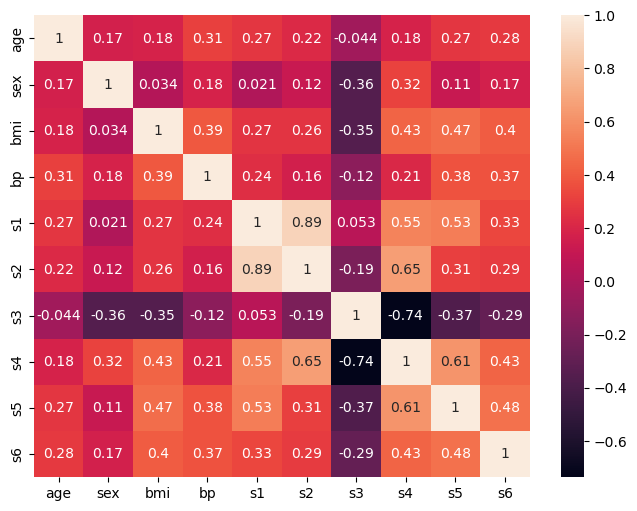

In [14]:
import seaborn as sns
plt.figure(figsize=(8, 6))
sns.heatmap(x_train.corr(), annot=True)

In [15]:
from sklearn.tree import DecisionTreeRegressor
tree_regg = DecisionTreeRegressor()

In [16]:
tree_regg.fit(x_train, y_train)

DecisionTreeRegressor()

In [24]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [21]:
base_y_pred = tree_regg.predict(x_test)

In [25]:
print("MAE - ", mean_absolute_error(y_test, base_y_pred))
print("MSE - ", mean_squared_error(y_test, base_y_pred))
print("R2 - ", r2_score(y_test, base_y_pred))

MAE -  56.79775280898876
MSE -  5474.348314606742
R2 -  -0.03325623244737619


### Hyperparameter Tuning --

In [26]:
regg = DecisionTreeRegressor()

In [27]:
from sklearn.model_selection import GridSearchCV

In [29]:
param = {
    'criterion' : ['squared_error', 'absolute_error', 'poisson'],
    'splitter' : ['best', 'random'],
    'max_depth' : [1, 2, 3, 4, 5, 7, 8, 10],
    'max_features' : ['auto', 'sqrt', 'log2']
}

In [31]:
grid = GridSearchCV(regg, param_grid=param, cv=5, n_jobs=-1, scoring='neg_root_mean_squared_error')

In [33]:
import warnings
warnings.filterwarnings('ignore')
grid.fit(x_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeRegressor(), n_jobs=-1,
             param_grid={'criterion': ['squared_error', 'absolute_error',
                                       'poisson'],
                         'max_depth': [1, 2, 3, 4, 5, 7, 8, 10],
                         'max_features': ['auto', 'sqrt', 'log2'],
                         'splitter': ['best', 'random']},
             scoring='neg_root_mean_squared_error')

In [34]:
grid.best_params_

{'criterion': 'squared_error',
 'max_depth': 4,
 'max_features': 'log2',
 'splitter': 'best'}

In [35]:
grid_y_pred = grid.predict(x_test)

In [36]:
print("MAE - ", mean_absolute_error(y_test, grid_y_pred))
print("MSE - ", mean_squared_error(y_test, grid_y_pred))
print("R2 - ", r2_score(y_test, grid_y_pred))

MAE -  46.0341417384114
MSE -  3406.317987655034
R2 -  0.357074287536451


## Final model 

In [37]:
model =  DecisionTreeRegressor(criterion='squared_error', max_depth=4, max_features='log2', splitter='best')

In [38]:
model.fit(x_train, y_train)

DecisionTreeRegressor(max_depth=4, max_features='log2')

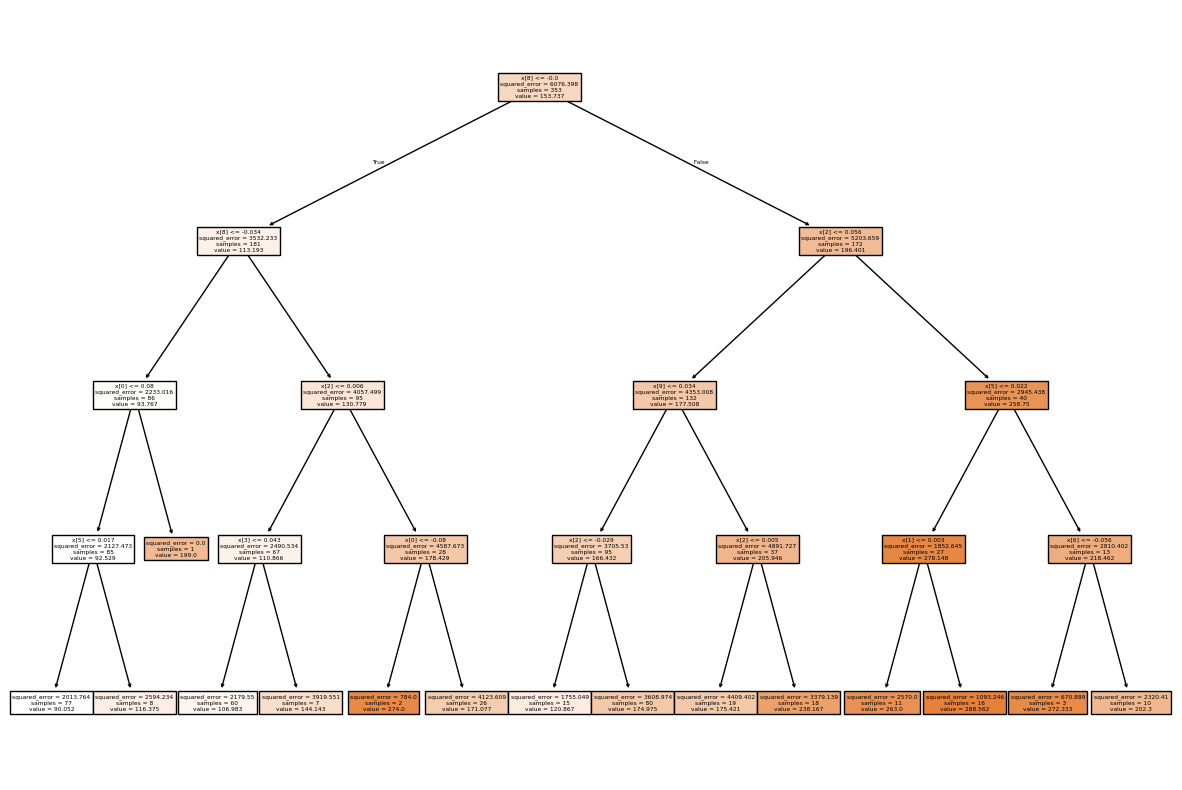

In [43]:
from sklearn import tree
plt.figure(figsize=(15, 10))
tree.plot_tree(model, filled=True)
plt.savefig('Tree.png')
plt.show()